In [2]:
# Transformers example -> Reverseing sequence of numbers


In [3]:
import haiku as hk
import jax
import jax.numpy as jnp
import jax.random as jrandom
import numpy as np
import optax

from probjax.nn.transformers import Transformer
from sbi.analysis import pairplot

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [4]:
jax.devices()

[CpuDevice(id=0)]

In [5]:
def generate_data(key, n):
    key1, key2, key3 = jrandom.split(key,3)
    theta1 = jrandom.normal(key1, (n, 1))  * 3
    x1 = 2*jnp.sin(theta1) + jrandom.normal(key2, (n, 1)) * 0.5
    #x3 = theta1 + jrandom.normal(key2, (n, 1)) * 0.5
    # x2 = 2*jnp.sin(theta1) + jrandom.normal(key3, (n, 1)) * 0.1
    # x2 = .3*theta1 + 10 + jrandom.normal(key, (n, 1))
    # x3 = jnp.sin(theta1) + jrandom.normal(key, (n, 1))
    # x4 = jnp.cos(theta1) + jrandom.normal(key, (n, 1))
    return jnp.concatenate([theta1,x1], axis=1).reshape(n, -1, 1)


data = generate_data(jrandom.PRNGKey(1), 10000)
mean = data.mean(axis=0)
std = data.std(axis=0)
T_max = data.shape[1]

node_ids = jnp.arange(T_max)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

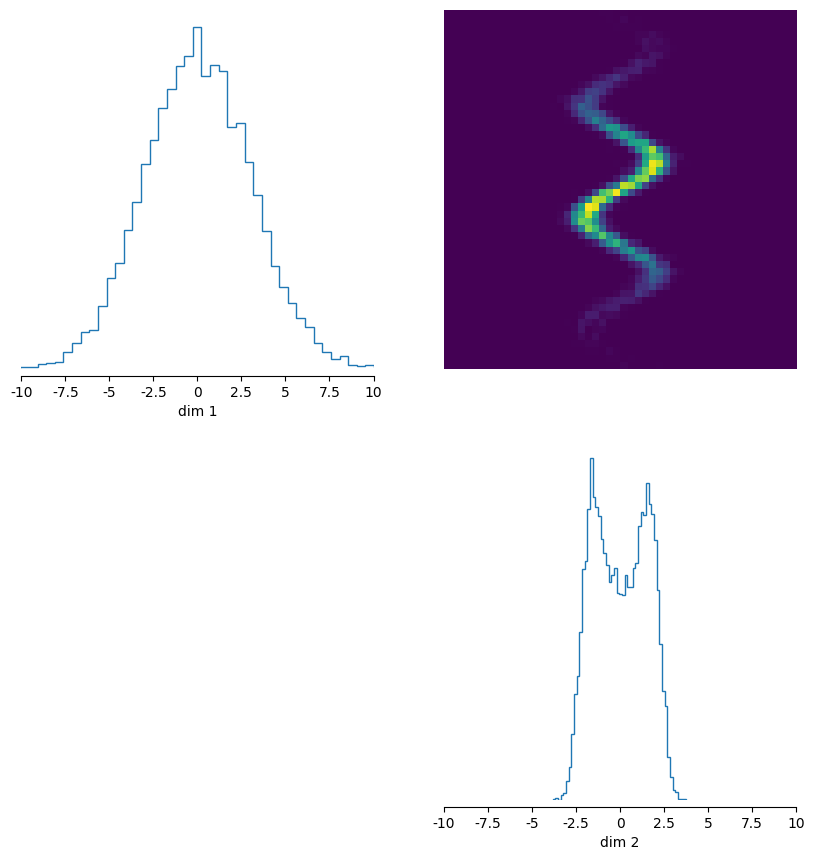

In [6]:
pairplot(np.array(data[:, :, 0]), limits=[[-10, 10], [-10, 10], [-10, 10]])

In [7]:
key = jrandom.PRNGKey(0)

In [8]:

from probjax.distributions import Independent, Normal

In [20]:

def model(node_ids, node_values, condition_mask):

    node_ids = node_ids.astype(jnp.int32)
    node_ids = jnp.reshape(node_ids, (-1, T_max, 1))
    node_values = jnp.reshape(node_values, (-1, T_max, 1))
    condition_mask = jnp.reshape(condition_mask, (-1, T_max, 1)).astype(jnp.bool_)

    dim = 150
    _dim = int(dim) // 2

    embed_node_ids = hk.Embed(T_max, _dim)
    embed_node_values = hk.Linear(_dim)
    condtion_embedding = hk.get_parameter("condtion_embedding", shape=[1,1, dim], dtype=jnp.float32, init=hk.initializers.RandomNormal(0.5))


    model = Transformer(num_heads=4, num_layers=8, attn_size=40, dropout_rate=None)

    embedding_node_ids = embed_node_ids(node_ids)
    embedding_node_ids = jnp.reshape(embedding_node_ids, (-1, T_max, _dim))
    embedding_node_values = embed_node_values(node_values)
    embedding_node_values = jnp.reshape(embedding_node_values, (-1, T_max, _dim))

    embedding_node_ids = jnp.broadcast_to(embedding_node_ids, embedding_node_values.shape)

    x_encoded = jnp.concatenate([embedding_node_ids, embedding_node_values], axis=-1)
    x_encoded = x_encoded + condtion_embedding * condition_mask


    h = model(x_encoded, context=None)

    mixtures = hk.Linear(50)(h)
    means = hk.Linear(50)(h)
    stds = hk.Linear(50)(h)

    mixtures = jax.nn.softmax(jnp.mean(mixtures, -2), axis=-1)
    stds = jnp.transpose(jax.nn.sigmoid(stds), (0,2,1))
    means = jnp.transpose(means, (0,2,1))

    return mixtures, means, stds


In [21]:
init, model_fn = hk.transform(model)

params = init(key, node_ids, jnp.zeros((1,2,1)), jnp.array([0, 0]))
out = model_fn(params, key, node_ids, jnp.zeros((5,2,1)), jnp.zeros((5,2,1), dtype=int))

In [22]:
from probjax.distributions import Mixture

pi, m, s = out
component_distribution = Independent(Normal(m, s), 1)
p = Mixture(pi, component_distributions=component_distribution)


In [23]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

@jax.jit
def loss_fn(params, key, batch_size= 512):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)

    # Generate data
    batch_xs = generate_data(rng_data, batch_size) # n, T_max, 1

    # Generate condition mask
    condition_mask = jax.random.choice(rng_condition, jnp.array([[0,0], [1,0], [0,1]]), shape=(batch_size,), p=jnp.array([0.33, 0.33, 0.33]), axis=0)
    condition_mask = condition_mask[..., None]

    # Permute sequence -> randomly permute the sequence of data to promote node identification
    node_values = jnp.zeros_like(batch_xs) + condition_mask * batch_xs

    pi, m, s = model_fn(params, rng_model, node_ids, node_values, condition_mask)
    condition_mask = jnp.transpose(condition_mask, (0,2,1))
    component_distribution = Normal(m, s)
    component_log_probs = component_distribution.log_prob(jnp.squeeze(batch_xs, -1)[:, None, :]) * (1 - condition_mask)
    component_log_probs = component_log_probs.sum(-1)
    mixture_log_prob = jnp.log(pi) + component_log_probs
    #print(mixture_log_prob.shape)
    log_probs = jax.scipy.special.logsumexp(mixture_log_prob, axis=-1)


    loss = -jnp.mean(log_probs)
    return loss


@jax.jit
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [24]:
# This takes forever to compile ... Probably due to splines with vmap -> Actually no, probably due to transformer also getting transformation as input
_ = update(params, key, opt_state)

In [40]:
key = jrandom.PRNGKey(0)
for _ in range(5):
    l = 0
    for i in range(500):
        key, subkey = jrandom.split(key)
        loss, params, opt_state = update(params, subkey, opt_state)
        l += loss / 500
    print(l)

1.9054874
1.9000579
1.8930682
1.8992507
1.8882941


In [41]:

def sample_fn(key, shape, node_ids=node_ids, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    node_values = jnp.zeros( (len(node_ids),)) + condition_mask * condition_value
    pi, m, s = model_fn(params, key, node_ids, node_values, condition_mask)
    component_distribution = Independent(Normal(m, s), 1)
    p = Mixture(pi, component_distributions=component_distribution)

    samples = jnp.squeeze(p.sample(key, shape), -2)
    samples = condition_mask * condition_value + (1-condition_mask) * samples
    return samples

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

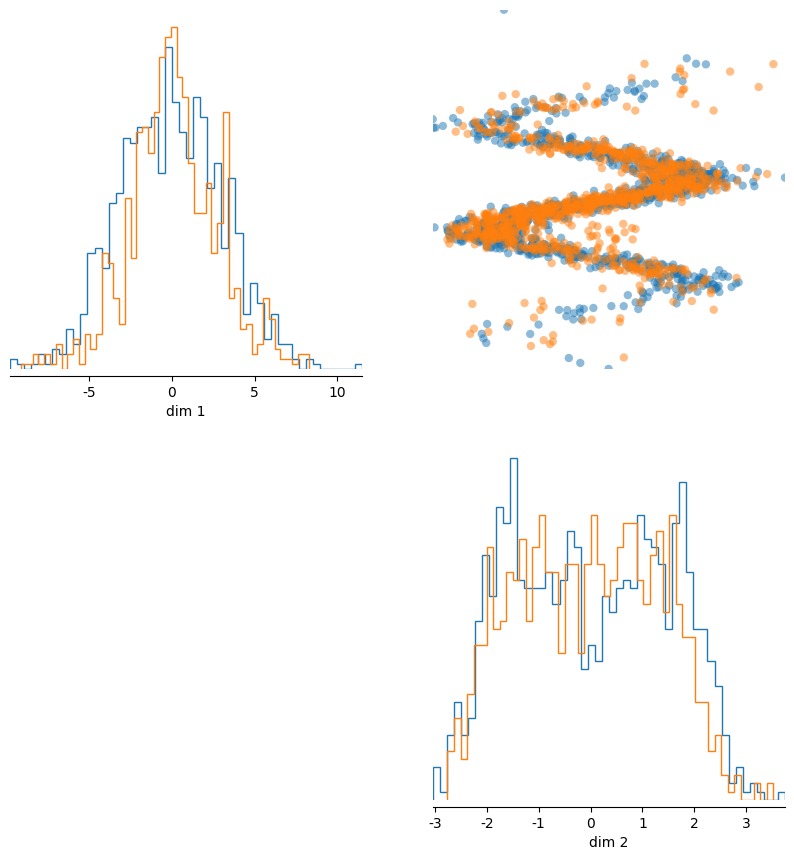

In [42]:

samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids)
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,:])], upper="scatter")

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

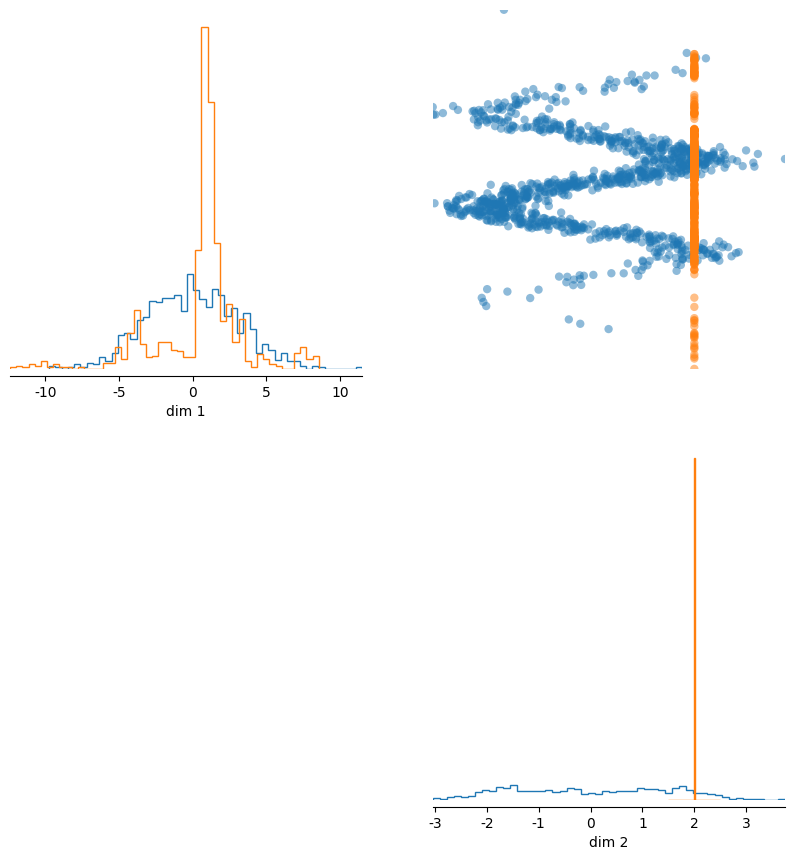

In [46]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,1]), condition_value=jnp.array([0., 2.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,:])], upper="scatter")

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

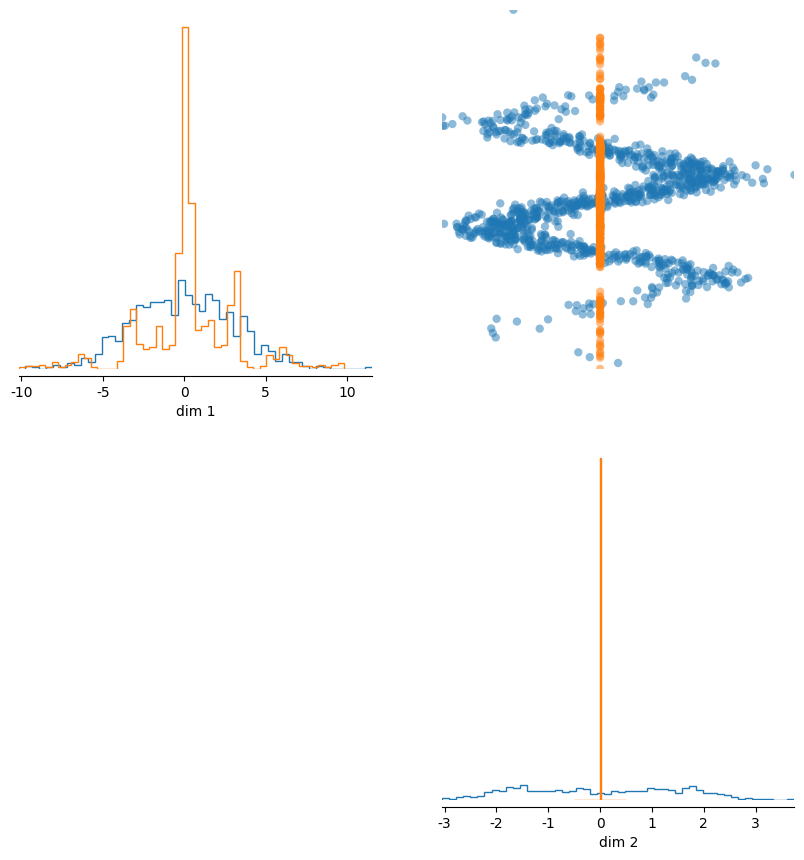

In [47]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,1]), condition_value=jnp.array([0., 0.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,:])], upper="scatter")

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

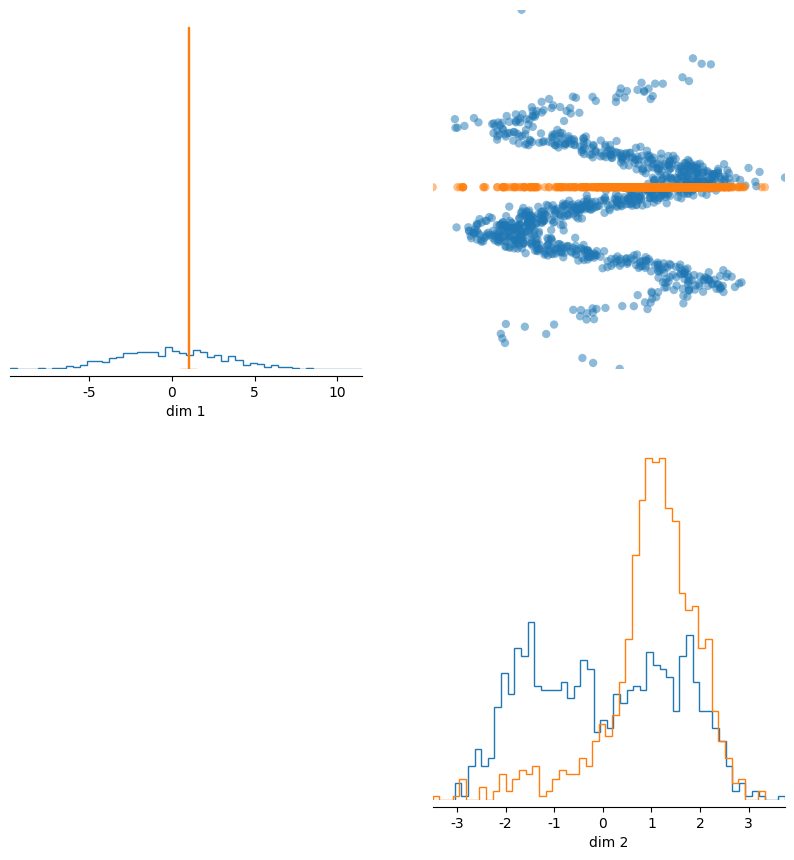

In [48]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([1,0]), condition_value=jnp.array([1., 2.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,:])], upper="scatter")